In [13]:
# Import necessary libraries
import pandas as pd  # for handling data in tabular form
import numpy as np  # for numerical operations
from sklearn.model_selection import train_test_split  # to split dataset into training and testing
from sklearn.preprocessing import StandardScaler , LabelEncoder # to normalize features
from sklearn.neighbors import KNeighborsClassifier  # to use the KNN algorithm
from sklearn.metrics import accuracy_score, confusion_matrix  # for evaluation
import matplotlib.pyplot as plt  # for plotting
from matplotlib.colors import ListedColormap  # for coloring decision regions

In [2]:
# Step 1: Load the dataset from CSV file
data = pd.read_csv('Iris.csv')  # read the Iris dataset into a DataFrame

In [3]:
# Step 2: Remove the 'Id' column (not needed for classification)
data = data.drop(columns=['Id'])  # drop the Id column

In [4]:
# Step 3: Separate features (X) and target labels (y)
X = data.drop(columns=['Species'])  # X contains all columns except the target
y = data['Species']  # y contains the target variable (Species)

In [5]:
# Step 4: Normalize the feature values using StandardScaler
scaler = StandardScaler()  # create scaler object
X = scaler.fit_transform(X)  # fit scaler to features and transform them

In [14]:

# Step 5: Convert class labels to numeric using LabelEncoder
label_encoder = LabelEncoder()  # Create encoder
y_encoded = label_encoder.fit_transform(y)  # Convert class names to numbers


In [15]:

# Step 6: Split dataset into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=0
)

In [16]:

# Step 7: Try different values of K and print accuracy
print("K values and their accuracies:")
for k in range(1, 11):  # Loop from K = 1 to 10
    knn = KNeighborsClassifier(n_neighbors=k)  # Create model
    knn.fit(X_train, y_train)  # Train on training data
    y_pred = knn.predict(X_test)  # Predict on test data
    acc = accuracy_score(y_test, y_pred)  # Calculate accuracy
    print(f"K = {k} => Accuracy = {acc:.2f}")  # Show result


K values and their accuracies:
K = 1 => Accuracy = 0.97
K = 2 => Accuracy = 0.97
K = 3 => Accuracy = 0.97
K = 4 => Accuracy = 0.97
K = 5 => Accuracy = 1.00
K = 6 => Accuracy = 1.00
K = 7 => Accuracy = 1.00
K = 8 => Accuracy = 1.00
K = 9 => Accuracy = 1.00
K = 10 => Accuracy = 1.00


In [17]:

# Step 8: Choose best K (based on results above)
best_k = 3  # You can set the K with highest accuracy
knn = KNeighborsClassifier(n_neighbors=best_k)  # Create model with best K
knn.fit(X_train, y_train)  # Train again with best K
y_pred = knn.predict(X_test)  # Predict again

In [18]:
# Step 9: Show confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))  # Display confusion matrix



Confusion Matrix:
[[11  0  0]
 [ 0 13  0]
 [ 0  1  5]]


In [19]:

# Step 10: Plot decision boundaries (using first 2 features for 2D visualization)
def plot_decision_boundary(X, y, k):
    X_plot = X[:, :2]  # Use only first two features
    model = KNeighborsClassifier(n_neighbors=k)  # New model
    model.fit(X_plot, y)  # Train using 2D feature space

    # Create mesh grid for plotting decision regions
    x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
    y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    # Predict classes for each grid point
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)  # Reshape for plotting

    # Plotting decision boundary
    plt.figure(figsize=(8, 6))
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])  # Region colors
    plt.contourf(xx, yy, Z, cmap=cmap_light)  # Draw regions

    # Scatter plot of actual data
    plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y, edgecolor='k')  # Plot data points
    plt.title(f"Decision Boundary (K = {k})")  # Title
    plt.xlabel("Feature 1")  # X-axis label
    plt.ylabel("Feature 2")  # Y-axis label
    plt.show()  # Show plot

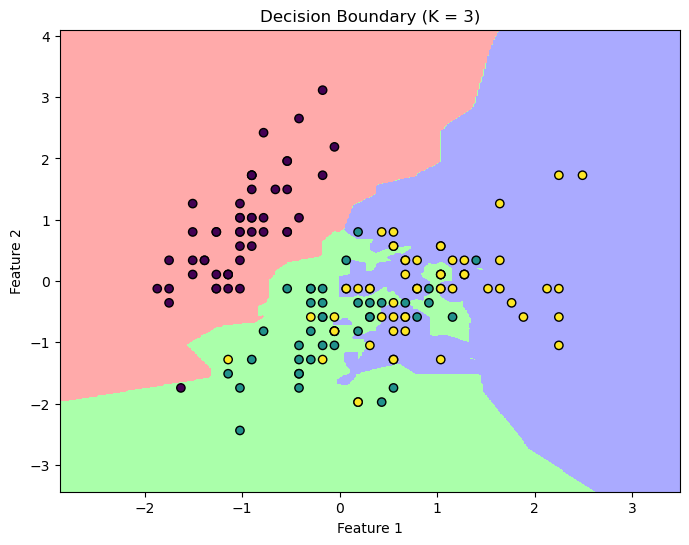

In [20]:
# Step 11: Call the function to display decision boundary
plot_decision_boundary(X, y_encoded, best_k)